In [1]:
from pathlib import Path
experimento = 'A'
path_carpeta = "../dataset/CSE-2018"
path_database = "05-01-06-prepared-dataset-no-dup-L1-all-labels.csv"
path_input = f'{path_carpeta}/{path_database}';
path_output = Path(f"dataset/{experimento}-02-dataset-balanceado.csv")
name_target = "LABEL"

In [2]:
import pandas as pd
data = pd.read_csv(str(f'{path_carpeta}/{path_database}'))
#data = data.sample(n=300000, random_state=42) # Tomar un subconjunto de prueba
x = data.drop([name_target], axis=1)
y = data[name_target]

LABEL
0     2670478
2      668461
1      576175
3      434873
4      282310
5      160604
6      117322
7       41455
14      39346
13      19462
8       10285
9        1730
10        611
11        230
12         87
Name: count, dtype: int64


<BarContainer object of 15 artists>

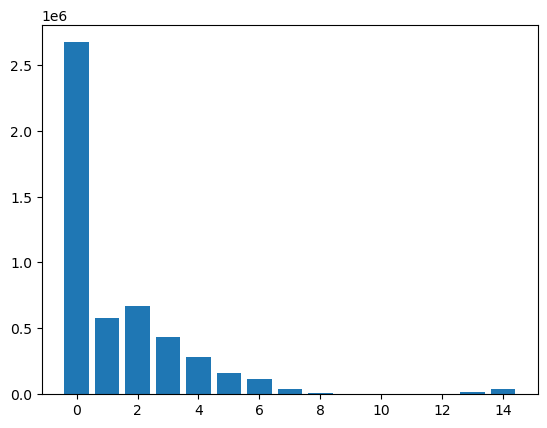

In [3]:
import matplotlib.pyplot as plt
n_values = y.value_counts()
print(n_values)
plt.bar(n_values.index, n_values.values)

LABEL
0     2670478
1     2670478
2     2670478
3     2670478
4     2670478
5     2670478
6     2670478
7     2670478
8     2670478
9     2670478
10    2670478
11    2670478
12    2670478
13    2670478
14    2670478
Name: count, dtype: int64


<BarContainer object of 15 artists>

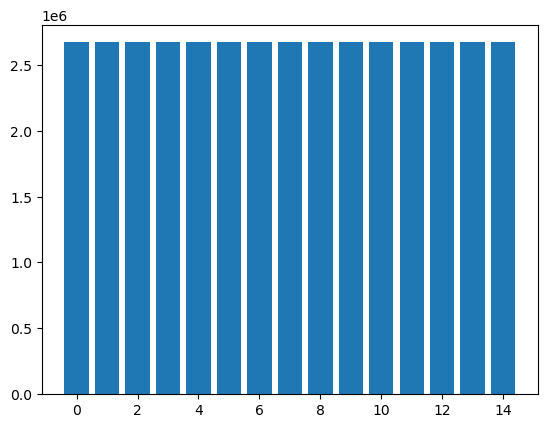

In [4]:
from imblearn.over_sampling import SMOTE

smote=SMOTE(sampling_strategy='not majority', random_state=42) 
x_resampled,y_resampled=smote.fit_resample(x,y)
n_values = y_resampled.value_counts()
print(n_values)
plt.bar(n_values.index, n_values.values)

In [5]:
# Unimos x e y en un único DataFrame
df_resampleado = x_resampled.copy()
df_resampleado[name_target] = y_resampled

# Guardamos en CSV
df_resampleado.to_csv(path_output, index=False, encoding="utf-8")